## 1. Setup, reproducibility & environment

In [1]:
import os, random, json, math, time
import numpy as np
import tensorflow as tf

# ---- Reproducibility -------------------------------------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)  # seeds python/numpy/tf together (TF 2.7+)

print("TensorFlow:", tf.__version__)
print("Keras     :", tf.keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs      :", gpus)

# ---- Mixed precision (faster on T4/P100, keeps a float32 softmax) ----------
# Safe: the final Dense layer is forced to float32 dtype later, so logits/probs
# stay numerically stable and TFLite conversion is unaffected.
if gpus:
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision: mixed_float16")
    except Exception as e:
        print("Mixed precision unavailable:", e)

2026-06-03 15:40:15.597671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780501215.841295      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780501215.916055      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780501216.490176      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780501216.490225      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780501216.490228      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Keras     : 3.13.2
GPUs      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision: mixed_float16


In [ ]:
# ---- Hyperparameters / config ---------------------------------------------
IMG_SIZE   = (224, 224)        # EfficientNetB0 native size; mobile-friendly
BATCH_SIZE = 32

# 38 PlantVillage disease classes (indices 0-37) + 1 "Not_A_Leaf" reject class
# (index 38). The reject class is trained on diverse non-leaf images so the app
# can say "not a leaf" instead of hallucinating a disease on random photos.
NUM_PLANT_CLASSES = 38
NOT_A_LEAF_INDEX  = 38
NUM_CLASSES       = 39

HEAD_EPOCHS     = 8            # phase 1: train classifier head only
FINETUNE_EPOCHS = 12           # phase 2: unfreeze top blocks, fine-tune
UNFREEZE_FROM   = 150          # unfreeze backbone layers from this index up
HEAD_LR     = 1e-3
FINETUNE_LR = 1e-5

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
os.makedirs(OUT_DIR, exist_ok=True)
print("Output dir:", OUT_DIR)


## 2. Load data & lock down class order

In [3]:
import glob

def find_split_dirs():
    """Locate train/ and valid/ dirs regardless of the exact nesting."""
    roots = glob.glob("/kaggle/input/**/train", recursive=True)
    if not roots:
        raise FileNotFoundError(
            "Could not find a 'train' folder under /kaggle/input. "
            "Add the 'New Plant Diseases Dataset' via Add Input.")
    train_dir = sorted(roots, key=len)[0]
    base = os.path.dirname(train_dir)
    valid_dir = os.path.join(base, "valid")
    if not os.path.isdir(valid_dir):
        valid_dir = os.path.join(base, "val")
    return train_dir, valid_dir

TRAIN_DIR, VALID_DIR = find_split_dirs()
print("train:", TRAIN_DIR)
print("valid:", VALID_DIR)

train: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
valid: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels="inferred", label_mode="int",  # int labels -> sparse CE
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, labels="inferred", label_mode="int",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

# The 38 plant folders sorted alphabetically -> indices 0..37 (matches disease_guide.json).
plant_class_names = train_ds_raw.class_names
assert len(plant_class_names) == NUM_PLANT_CLASSES, \
    f"Expected {NUM_PLANT_CLASSES} plant classes, got {len(plant_class_names)}"
assert plant_class_names == val_ds_raw.class_names, "train/valid class order mismatch!"

# Append the out-of-distribution reject class as the FINAL index (38). We add it
# manually (not as a folder) so the 38 disease indices are never reshuffled.
class_names = list(plant_class_names) + ["Not_A_Leaf"]
assert len(class_names) == NUM_CLASSES

# Persist the canonical index -> name mapping for the app & API (now 39 entries).
with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump({i: n for i, n in enumerate(class_names)}, f, indent=2)

for i, n in enumerate(class_names):
    print(f"{i:2d}: {n}")


## 3. Performance pipeline & augmentation

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
import glob

# ---------------------------------------------------------------------------
# NEGATIVE ("Not a leaf") images
# ---------------------------------------------------------------------------
# Teach the model to REJECT non-leaf photos by adding diverse public datasets as
# extra Kaggle Inputs and labelling them all with NOT_A_LEAF_INDEX (38).
#
#   *** In the Kaggle sidebar: Add Input -> add BOTH of these datasets ***
#     - "Intel Image Classification"  (puneet6060/intel-image-classification)
#     - "Caltech 256"                 (jessicali9530/caltech256)
#
# /kaggle/input is READ-ONLY, so we build a SEPARATE pipeline and concatenate it.
# We must NOT drop a folder into the plant dataset: that would re-sort the 38
# class folders alphabetically and shift every disease index.

# Folder/path keywords to drop so the reject class never contains leaf-like
# images. (Avoid substrings that collide with real negatives, e.g. "tree" would
# match "street".)
PLANT_LIKE = ("forest", "bonsai", "fern", "grape", "sunflower", "mushroom",
              "watermelon", "tomato", "cactus", "hibiscus", "palm-tree",
              "iris", "lotus", "leaf", "leaves", "plant", "flower")

# Robust auto-discovery: treat EVERY image under /kaggle/input that is NOT inside
# the plant dataset as a negative. This works no matter what the extra datasets
# are named or how deeply Kaggle nests them (Caltech mounts as
# 256_ObjectCategories/, Intel as seg_train/..., etc.) -- we never hardcode slugs.
PLANT_ROOT = os.path.join("/kaggle/input",
                          os.path.relpath(TRAIN_DIR, "/kaggle/input").split(os.sep)[0])
print("Plant dataset root (excluded from negatives):", PLANT_ROOT)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")
neg_paths = []
for root, _dirs, files in os.walk("/kaggle/input"):
    if root.startswith(PLANT_ROOT):      # skip the leaf dataset
        continue
    if any(k in root.lower() for k in PLANT_LIKE):  # skip leaf-like subfolders
        continue
    for fn in files:
        if fn.lower().endswith(IMG_EXTS):
            neg_paths.append(os.path.join(root, fn))

neg_paths = [p for p in neg_paths if not any(k in p.lower() for k in PLANT_LIKE)]
random.Random(SEED).shuffle(neg_paths)
neg_paths = neg_paths[:12000]          # ~8-15k diverse negatives is plenty

print(f"Found {len(neg_paths)} candidate negative images.")
assert neg_paths, (
    "No negative images found under /kaggle/input. In the Kaggle sidebar use "
    "'Add Input' to add at least one non-leaf image dataset (e.g. 'Intel Image "
    "Classification' and 'Caltech 256'), then re-run.")
n_val = max(1, int(0.1 * len(neg_paths)))
neg_val_paths, neg_train_paths = neg_paths[:n_val], neg_paths[n_val:]
print(f"Negatives -> {len(neg_train_paths)} train / {len(neg_val_paths)} val")

def _neg_ds(paths):
    def _load(p):
        img = tf.io.decode_image(tf.io.read_file(p), channels=3,
                                 expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)   # float32 [0,255], matches baked-in preprocess
        return img, tf.constant(NOT_A_LEAF_INDEX, tf.int32)
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())  # skip any corrupt files
    return ds.batch(BATCH_SIZE)

# Merge leaves + negatives. Shuffle the merged TRAIN stream so negative batches
# aren't all clustered at the end of each epoch. (Do NOT .cache(): see note below.)
train_ds = (train_ds_raw
            .concatenate(_neg_ds(neg_train_paths))
            .shuffle(2048, seed=SEED)
            .prefetch(AUTOTUNE))
val_ds = val_ds_raw.concatenate(_neg_ds(neg_val_paths)).prefetch(AUTOTUNE)

# ---------------------------------------------------------------------------
# Class weights — one reject class (~11k imgs) vs 70k leaf images would be
# under-weighted. Counting via file listing avoids a slow full decode pass.
# ---------------------------------------------------------------------------
counts = [len(os.listdir(os.path.join(TRAIN_DIR, n))) for n in class_names[:NOT_A_LEAF_INDEX]]
counts.append(len(neg_train_paths))
counts = np.asarray(counts, dtype=np.float64)
total = counts.sum()
class_weight = {i: float(total / (NUM_CLASSES * c)) for i, c in enumerate(counts)}
print(f"reject-class weight: {class_weight[NOT_A_LEAF_INDEX]:.2f}")

# NOTE: do NOT use .cache() here. With ~80k images at 224x224x3 float32 an in-RAM
# cache needs tens of GB and gets OOM-killed on Kaggle (~13-16 GB RAM). Prefetch
# alone is fine; images are re-decoded each epoch with GPU + AUTOTUNE.

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")


## 4. Build the model (self-contained preprocessing)

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_model():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="image")
    x = data_augmentation(inputs)
    x = preprocess_input(x)                     # EfficientNet scaling, baked in
    backbone = EfficientNetB0(include_top=False, weights="imagenet",
                              input_tensor=x, pooling="avg")
    backbone.trainable = False                  # phase 1: frozen
    x = tf.keras.layers.Dropout(0.3, name="top_dropout")(backbone.output)
    outputs = tf.keras.layers.Dense(
        NUM_CLASSES, activation="softmax", dtype="float32", name="predictions")(x)
    return tf.keras.Model(inputs, outputs, name="smartleaf_efficientnetb0"), backbone

model, backbone = build_model()
model.compile(optimizer=tf.keras.optimizers.Adam(HEAD_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "smartleaf_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 5. Callbacks (anti-overfitting + checkpointing)

In [7]:
ckpt_path = os.path.join(OUT_DIR, "best_model.keras")
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path, monitor="val_accuracy", mode="max",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max", patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

## 6. Phase 1 — train the classifier head

In [ ]:
hist_head = model.fit(train_ds, validation_data=val_ds,
                      epochs=HEAD_EPOCHS, callbacks=callbacks,
                      class_weight=class_weight)


## 7. Phase 2 — fine-tune the top backbone blocks

In [ ]:
backbone.trainable = True
for layer in backbone.layers[:UNFREEZE_FROM]:
    layer.trainable = False
# Keep BatchNorm frozen everywhere to stabilize fine-tuning.
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in model.layers + backbone.layers if l.trainable)
print("Trainable layers now:", trainable)

model.compile(optimizer=tf.keras.optimizers.Adam(FINETUNE_LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist_ft = model.fit(train_ds, validation_data=val_ds,
                    epochs=FINETUNE_EPOCHS, callbacks=callbacks,
                    class_weight=class_weight)


## 8. Training curves — inspect the train/val gap

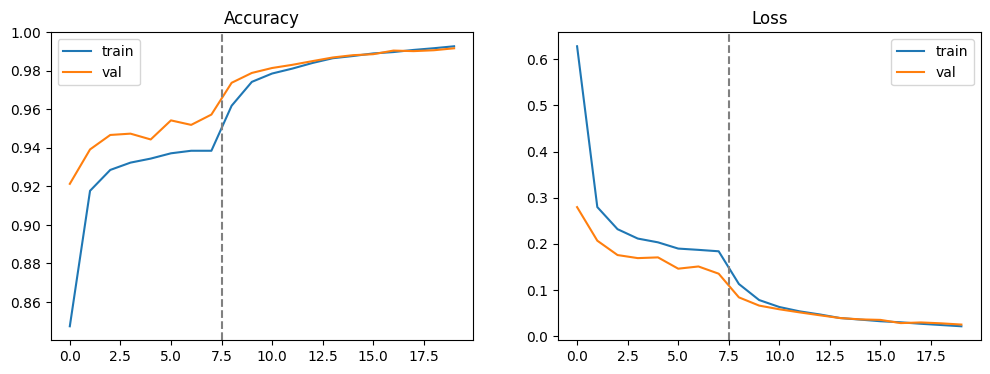

Best val accuracy: 0.9917


In [10]:
import matplotlib.pyplot as plt

def merge(key):
    return hist_head.history.get(key, []) + hist_ft.history.get(key, [])

acc, val_acc = merge("accuracy"), merge("val_accuracy")
loss, val_loss = merge("loss"), merge("val_loss")
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="train")
plt.plot(epochs_range, val_acc, label="val")
plt.axvline(HEAD_EPOCHS - 0.5, ls="--", c="gray")
plt.title("Accuracy"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="train")
plt.plot(epochs_range, val_loss, label="val")
plt.axvline(HEAD_EPOCHS - 0.5, ls="--", c="gray")
plt.title("Loss"); plt.legend()
plt.show()

print(f"Best val accuracy: {max(val_acc):.4f}")

## 9. Evaluate (target: > 95%)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Pull labels from the merged val_ds so leaves AND negatives are evaluated, and
# in the SAME order model.predict iterates them.
y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_prob = model.predict(val_ds)               # softmax probabilities
y_pred = y_prob.argmax(axis=1)

val_acc_final = (y_pred == y_true).mean()
print(f"Validation accuracy (leaves + negatives): {val_acc_final:.4f}")
assert val_acc_final > 0.95, "Below 95% — train longer / unfreeze more / check data."

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Focused check on the reject class: how well do we catch non-leaves?
nl = NOT_A_LEAF_INDEX
tp = int(((y_pred == nl) & (y_true == nl)).sum())
fn = int(((y_pred != nl) & (y_true == nl)).sum())
fp = int(((y_pred == nl) & (y_true != nl)).sum())
recall = tp / (tp + fn + 1e-9); precision = tp / (tp + fp + 1e-9)
print(f"Not_A_Leaf -> recall {recall:.3f} (caught non-leaves), "
      f"precision {precision:.3f} (leaves wrongly rejected: {fp})")


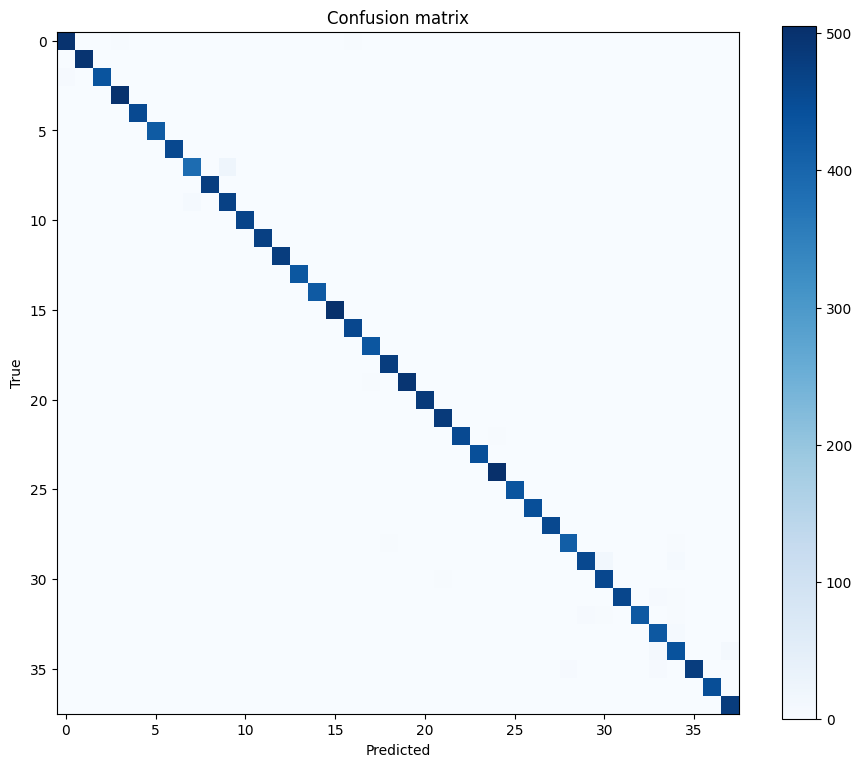

Top confusions (true -> predicted : count):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight : 22
  Tomato___Early_blight -> Tomato___Late_blight : 14
  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite : 9
  Tomato___Target_Spot -> Tomato___healthy : 8
  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 7
  Tomato___Early_blight -> Tomato___Target_Spot : 7
  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot : 6
  Tomato___Tomato_Yellow_Leaf_Curl_Virus -> Tomato___Spider_mites Two-spotted_spider_mite : 5
  Tomato___Leaf_Mold -> Tomato___Spider_mites Two-spotted_spider_mite : 4
  Apple___Cedar_apple_rust -> Apple___Apple_scab : 4


In [12]:
# Confusion matrix + the most-confused class pairs (where to focus data effort).
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(11, 9))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.colorbar(); plt.show()

cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
print("Top confusions (true -> predicted : count):")
for t, p in zip(*np.unravel_index(np.argsort(cm_off, axis=None)[::-1][:10], cm.shape)):
    if cm_off[t, p] > 0:
        print(f"  {class_names[t]} -> {class_names[p]} : {cm_off[t, p]}")

## 10. Calibration & anti-hallucination (temperature scaling + uncertainty)

In [13]:
# We already have softmax probabilities (y_prob). Recover logits as log(probs):
# softmax(log(p)/T) is the standard temperature-scaling form and is numerically stable.
eps = 1e-7
val_logits = np.log(np.clip(y_prob, eps, 1.0))

def nll_for_temperature(T):
    z = val_logits / T
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z); p /= p.sum(axis=1, keepdims=True)
    return -np.mean(np.log(p[np.arange(len(y_true)), y_true] + eps))

# 1-D search for the temperature minimizing validation NLL.
Ts = np.linspace(0.5, 5.0, 91)
T_opt = float(Ts[np.argmin([nll_for_temperature(t) for t in Ts])])
print(f"Optimal temperature T = {T_opt:.3f}  (T>1 => was over-confident)")

Optimal temperature T = 1.050  (T>1 => was over-confident)


In [14]:
CONF_THRESHOLD = 0.60     # reject if calibrated top prob below this
ENTROPY_FRAC   = 0.55     # reject if entropy > this fraction of max entropy
MAX_ENTROPY = math.log(NUM_CLASSES)

def calibrate(probs, T=T_opt):
    """Apply temperature scaling to a batch of softmax probabilities."""
    z = np.log(np.clip(probs, eps, 1.0)) / T
    z = z - z.max(axis=-1, keepdims=True)
    p = np.exp(z); return p / p.sum(axis=-1, keepdims=True)

def decide(probs):
    """Return (is_confident, reason) for a single calibrated prob vector."""
    top = float(probs.max())
    ent = float(-(probs * np.log(probs + eps)).sum())
    if top < CONF_THRESHOLD:
        return False, f"low confidence ({top:.2f} < {CONF_THRESHOLD})"
    if ent > ENTROPY_FRAC * MAX_ENTROPY:
        return False, f"high entropy ({ent:.2f})"
    return True, "confident"

# Report how calibration shifts mean confidence on correct vs wrong predictions.
cal = calibrate(y_prob)
correct = y_pred == y_true
print(f"Mean top-prob  raw: {y_prob.max(1).mean():.3f}   calibrated: {cal.max(1).mean():.3f}")
print(f"Calibrated mean conf | correct: {cal.max(1)[correct].mean():.3f} "
      f"| wrong: {cal.max(1)[~correct].mean():.3f}")

Mean top-prob  raw: 0.992   calibrated: 0.992
Calibrated mean conf | correct: 0.994 | wrong: 0.745


## 11. Inference helpers (mirror the API's response shape)

In [15]:
from PIL import Image

def confidence_level(c):
    return "High" if c >= 0.80 else "Medium" if c >= 0.50 else "Low"

def load_image(path):
    """224x224 RGB float32 in [0,255] (matches the model's baked-in preprocessing)."""
    img = Image.open(path).convert("RGB").resize(IMG_SIZE, Image.Resampling.LANCZOS)
    return np.expand_dims(np.asarray(img, dtype=np.float32), 0)

def load_and_predict(path, model=model, T=T_opt, topk=5):
    probs = calibrate(model.predict(load_image(path), verbose=0), T)[0]
    idx = int(probs.argmax()); conf = float(probs[idx])
    ok, reason = decide(probs)
    order = probs.argsort()[::-1][:topk]
    return {
        "predicted_class_index": idx,
        "label": class_names[idx],
        "confidence": round(conf, 4),
        "confidence_level": confidence_level(conf),
        "is_confident": ok,
        "verdict": class_names[idx] if ok else "Uncertain",
        "reason": reason,
        "all_predictions": [
            {"label": class_names[i], "confidence": round(float(probs[i]), 4),
             "confidence_level": confidence_level(float(probs[i]))} for i in order],
    }

# Smoke test on a couple of validation images.
sample = glob.glob(os.path.join(VALID_DIR, "*", "*"))[:2]
for s in sample:
    print(s.split(os.sep)[-2], "->", load_and_predict(s))

Tomato___Late_blight -> {'predicted_class_index': 30, 'label': 'Tomato___Late_blight', 'confidence': 0.9992, 'confidence_level': 'High', 'is_confident': True, 'verdict': 'Tomato___Late_blight', 'reason': 'confident', 'all_predictions': [{'label': 'Tomato___Late_blight', 'confidence': 0.9992, 'confidence_level': 'High'}, {'label': 'Tomato___Septoria_leaf_spot', 'confidence': 0.0004, 'confidence_level': 'Low'}, {'label': 'Potato___Early_blight', 'confidence': 0.0002, 'confidence_level': 'Low'}, {'label': 'Potato___Late_blight', 'confidence': 0.0001, 'confidence_level': 'Low'}, {'label': 'Tomato___Early_blight', 'confidence': 0.0, 'confidence_level': 'Low'}]}
Tomato___Late_blight -> {'predicted_class_index': 30, 'label': 'Tomato___Late_blight', 'confidence': 1.0, 'confidence_level': 'High', 'is_confident': True, 'verdict': 'Tomato___Late_blight', 'reason': 'confident', 'all_predictions': [{'label': 'Tomato___Late_blight', 'confidence': 1.0, 'confidence_level': 'High'}, {'label': 'Tomato__

## 12. Save — `.keras` (API) and Float16 `.tflite` (app)

In [16]:
# --- Reset to float32 so the converter isn't fighting mixed-precision casts ---
tf.keras.mixed_precision.set_global_policy("float32")

# --- Rebuild WITHOUT the augmentation block (inference graph only) ---
def build_inference_model():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="image")
    x = preprocess_input(inputs)                       # no data_augmentation here
    bb = EfficientNetB0(include_top=False, weights=None,
                        input_tensor=x, pooling="avg")
    x = tf.keras.layers.Dropout(0.3, name="top_dropout")(bb.output)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax",
                                dtype="float32", name="predictions")(x)
    return tf.keras.Model(inputs, out, name="smartleaf_infer")

infer_model = build_inference_model()
infer_model.set_weights(model.get_weights())   # augmentation/dropout carry no weights → lists align

# 1) Keras format (drop-in for the FastAPI service).
keras_path = os.path.join(OUT_DIR, "best_model.keras")
model.save(keras_path)
print("Saved:", keras_path)

# 2) Float16 TFLite for the app — Keras-3-safe path: export a SavedModel, then convert.
saved_dir = os.path.join(OUT_DIR, "smartleaf_savedmodel")
infer_model.export(saved_dir)                  # Keras 3: writes a TF SavedModel + serving signature

converter = tf.lite.TFLiteConverter.from_saved_model(saved_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_fp16 = converter.convert()
tflite_path = os.path.join(OUT_DIR, "smartleaf_fp16.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_fp16)
print(f"Saved: {tflite_path}  ({len(tflite_fp16)/1e6:.2f} MB)")

# 3) Inference config the app must mirror.
with open(os.path.join(OUT_DIR, "infer_config.json"), "w") as f:
    json.dump({"img_size": list(IMG_SIZE), "input_range": "[0,255] raw RGB",
               "temperature": round(T_opt, 4), "conf_threshold": CONF_THRESHOLD,
               "entropy_frac": ENTROPY_FRAC, "num_classes": NUM_CLASSES}, f, indent=2)
print("Saved: infer_config.json")

Saved: /kaggle/working/best_model.keras
INFO:tensorflow:Assets written to: /kaggle/working/smartleaf_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/smartleaf_savedmodel/assets


Saved artifact at '/kaggle/working/smartleaf_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  138409776519056: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138409776518864: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138409776522320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776521360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776515600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776520976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776523856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776521744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776521936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138409776519440: TensorSpec(shape=(), dtype=tf.resou

W0000 00:00:1780505818.619610      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780505818.619690      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780505818.837487      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Saved: /kaggle/working/smartleaf_fp16.tflite  (8.17 MB)
Saved: infer_config.json


## 13. TFLite sanity check — Keras vs TFLite must agree

In [ ]:
interpreter = tf.lite.Interpreter(model_content=tflite_fp16)
in_d = interpreter.get_input_details()[0]
out_d = interpreter.get_output_details()[0]

# SavedModel export may leave a dynamic batch dim; pin it to [1,224,224,3].
interpreter.resize_tensor_input(in_d["index"], [1, *IMG_SIZE, 3])
interpreter.allocate_tensors()
in_d = interpreter.get_input_details()[0]   # refresh after resize
out_d = interpreter.get_output_details()[0]

def tflite_predict_raw(arr):
    interpreter.set_tensor(in_d["index"], arr.astype(in_d["dtype"]))
    interpreter.invoke()
    return interpreter.get_tensor(out_d["index"])[0]

agree = 0
checks = glob.glob(os.path.join(VALID_DIR, "*", "*"))[:25]
for s in checks:
    arr = load_image(s)
    k = int(infer_model.predict(arr, verbose=0)[0].argmax())   # compare vs the converted graph
    t = int(tflite_predict_raw(arr).argmax())
    agree += (k == t)
print(f"Keras (infer_model) vs TFLite top-1 agreement: {agree}/{len(checks)}")
assert agree >= len(checks) - 1, "TFLite diverges from infer_model — investigate conversion."

def tflite_predict(path, T=T_opt, topk=5):
    """Same contract as load_and_predict(), but using the TFLite interpreter."""
    probs = calibrate(tflite_predict_raw(load_image(path))[None, :], T)[0]
    idx = int(probs.argmax()); ok, reason = decide(probs)
    order = probs.argsort()[::-1][:topk]
    return {"verdict": class_names[idx] if ok else "Uncertain",
            "label": class_names[idx], "confidence": round(float(probs[idx]), 4),
            "is_confident": ok, "reason": reason,
            "all_predictions": [{"label": class_names[i],
                                 "confidence": round(float(probs[i]), 4)} for i in order]}

print(tflite_predict(checks[0]))

# Reject-class smoke test: a handful of held-out NON-leaf images should all
# come back as "Not a leaf".
print("\nNon-leaf check (expect 'Not a leaf'):")
for s in neg_val_paths[:8]:
    print(f"  {os.path.basename(s):35s} -> {tflite_predict(s)['verdict']}")


In [20]:
import os
from IPython.display import FileLink, display

print("Files in /kaggle/working:")
for name in sorted(os.listdir("/kaggle/working")):
    p = os.path.join("/kaggle/working", name)
    if os.path.isfile(p):
        print(f"  {name}  ({os.path.getsize(p)/1e6:.2f} MB)")
    else:
        print(f"  {name}/  (folder)")

# Clickable download links (cwd is /kaggle/working by default)
for name in ["smartleaf_fp16.tflite", "infer_config.json", "best_model.keras"]:
    display(FileLink(name))

Files in /kaggle/working:
  __notebook__.ipynb  (20.86 MB)
  best_model.keras  (70.26 MB)
  class_names.json  (0.00 MB)
  infer_config.json  (0.00 MB)
  smartleaf_fp16.tflite  (8.17 MB)
  smartleaf_savedmodel/  (folder)


/kaggle/working/smartleaf_fp16.tflite

/kaggle/working/infer_config.json

/kaggle/working/best_model.keras